## Section 0: Pilot instance segmentation — lateral view (20 gambar)

Eksperimen pertama pendekatan **instance segmentation per-gigi** (beda dari notebook sebelumnya `02_yolo_rf.ipynb`/`03_yolo_rf_grade.ipynb` yang object detection buat grade/finding, bukan per-gigi). Tiap gigi jadi objek terpisah dengan mask sendiri — dibutuhkan buat isolasi insisivus & hitung jarak antar gigi di tahap pengukuran (crowding, overjet/overbite) nanti.

Tujuan notebook ini **bukan model final**, tapi validasi cepat: apakah 20 foto lateral yang sudah dianotasi manual (Smart Polygon di Roboflow, klik per gigi — auto-label text-prompt SAM3 dicoba duluan tapi gagal misahin gigi berdempetan) cukup buat model belajar sebelum invest anotasi 50-100 gambar lebih banyak.

Karena cuma 20 gambar, split train/valid/test dari Roboflow bakal sangat kecil — angka mAP di Section 4 cuma indikatif. Verifikasi utama tetap **visual overlay** di Section 5, sesuai 3 kriteria yang sudah disepakati: (1) jumlah instance masuk akal, (2) gigi berdempetan tetap terpisah, (3) tepi rapi.

## Section 1: Setup

In [1]:
%pip install -q ultralytics roboflow python-dotenv


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path

import yaml as pyyaml
import torch
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from ultralytics import YOLO

load_dotenv()

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Menggunakan device:", device)


Menggunakan device: mps


## Section 2: Download dataset dari Roboflow

Butuh `ROBOFLOW_API_KEY` di file `.env` di root project (sudah ditambahkan ke `.gitignore`, jangan hardcode key di notebook). Ambil dari Roboflow -> Settings -> API Keys.

`VERSION = 1` asumsi versi pertama yang di-generate dari tab **Versions** di project `malocclusion-lateral-seg` — kalau belum pernah generate versi di situ, generate dulu (dataset -> Versions -> Generate New Version), baru sesuaikan angkanya di sini kalau ternyata bukan 1.

In [3]:
from roboflow import Roboflow
import random
import shutil

WORKSPACE = "benediktas-workspace"
PROJECT = "malocclusion-lateral-seg"
VERSION = 2  # 108 foto (20 lama + tambahan baru), lihat catatan Section 0

YOLO_ROOT = Path(f"data/lateral_pilot_seg_v{VERSION}")  # folder per-versi, biar nggak ke-skip pakai data v1 lama
yaml_path = YOLO_ROOT / "data.yaml"


def has_images(split_name):
    d = YOLO_ROOT / split_name / "images"
    return d.exists() and any(d.glob("*.jpg"))


if has_images("train") and has_images("valid") and has_images("test"):
    print("Dataset sudah ada & sudah ke-split (train/valid/test terisi) -> skip re-download.")
    print("Hapus folder", YOLO_ROOT, "manual kalau memang mau paksa download ulang dari awal.")
else:
    api_key = os.getenv("ROBOFLOW_API_KEY")
    assert api_key, "Isi ROBOFLOW_API_KEY di file .env dulu (Roboflow > Settings > API Keys)"

    rf = Roboflow(api_key=api_key)
    project = rf.workspace(WORKSPACE).project(PROJECT)
    version = project.version(VERSION)
    dataset = version.download("yolov11", location=str(YOLO_ROOT))

    # Roboflow kadang taruh semua gambar ke split "train" doang (valid/test kosong/nggak ada
    # foldernya) kalau split-nya nggak di-assign manual pas upload. Auto-fix: kalau valid atau
    # test kosong, split lokal dari train (~85/8/7), biar training tetap bisa jalan.
    if not has_images("valid") or not has_images("test"):
        print("valid/test kosong -> split lokal dari train")
        train_img_dir = YOLO_ROOT / "train" / "images"
        train_lbl_dir = YOLO_ROOT / "train" / "labels"
        stems = sorted(p.stem for p in train_img_dir.glob("*.jpg"))
        random.seed(0)
        random.shuffle(stems)
        n = len(stems)
        n_valid = max(1, round(n * 0.15))
        n_test = max(1, round(n * 0.15))
        split_map = {"valid": stems[:n_valid], "test": stems[n_valid:n_valid + n_test]}
        for split_name, split_stems in split_map.items():
            img_out = YOLO_ROOT / split_name / "images"
            lbl_out = YOLO_ROOT / split_name / "labels"
            img_out.mkdir(parents=True, exist_ok=True)
            lbl_out.mkdir(parents=True, exist_ok=True)
            for stem in split_stems:
                shutil.move(str(train_img_dir / f"{stem}.jpg"), str(img_out / f"{stem}.jpg"))
                shutil.move(str(train_lbl_dir / f"{stem}.txt"), str(lbl_out / f"{stem}.txt"))
        print(f"train={n - n_valid - n_test}, valid={n_valid}, test={n_test}")

    # Roboflow nulis path relatif gaya "../train/images" tanpa key `path:` eksplisit -- rawan
    # salah resolve tergantung versi ultralytics. Tulis ulang biar jelas & tidak ambigu.
    yaml_content = (
        f"path: {YOLO_ROOT.resolve()}\n"
        "train: train/images\n"
        "val: valid/images\n"
        "test: test/images\n\n"
        "nc: 1\n"
        "names: ['tooth']\n"
    )
    yaml_path.write_text(yaml_content)

print(yaml_path.read_text())


Dataset sudah ada & sudah ke-split (train/valid/test terisi) -> skip re-download.
Hapus folder data/lateral_pilot_seg_v2 manual kalau memang mau paksa download ulang dari awal.
path: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/lateral_pilot_seg_v2
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['tooth']



## Section 3: Sanity check dataset

Cek jumlah gambar & label per split — karena cuma 20 gambar total, split-nya bakal kecil banget (kemungkinan besar cuma beberapa gambar di valid/test, mungkin malah 0 di salah satu split kalau Roboflow-nya kebagian ganjil).

In [4]:
with open(yaml_path) as f:
    data_cfg = pyyaml.safe_load(f)
print(data_cfg)

for split_key in ["train", "val", "test"]:
    split_rel = data_cfg.get(split_key)
    if not split_rel:
        print(f"[{split_key}] tidak ada di data.yaml")
        continue
    img_dir = YOLO_ROOT / split_rel
    label_dir = Path(str(img_dir).replace("/images", "/labels"))
    n_img = len(list(img_dir.glob("*.jpg"))) if img_dir.exists() else 0
    n_lbl = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0
    print(f"[{split_key}] images={n_img}, labels={n_lbl}")


{'path': '/Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/lateral_pilot_seg_v2', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 1, 'names': ['tooth']}
[train] images=76, labels=76
[val] images=16, labels=16
[test] images=16, labels=16


## Section 4: Training baseline

Model nano (`yolo11n-seg.pt`) — paling ringan, cukup buat pilot ini, belum perlu model besar. Epoch dinaikkan (100) + `patience` besar karena datanya sedikit banget (20 gambar), biar model sempet belajar dulu sebelum early-stop, tapi tetap berhenti otomatis kalau loss mentok.

In [5]:
model = YOLO("yolo11n-seg.pt")

results = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=800,
    batch=4,
    device=device,
    patience=20,
    project="lateral_pilot_runs",
    name="baseline_seg",
)


New https://pypi.org/project/ultralytics/8.4.110 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/lateral_pilot_seg_v2/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      1/100      4.35G     0.9214      1.585      2.837      1.035          0         66        800: 100% ━━━━━━━━━━━━ 19/19 1.9it/s 10.0s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1it/s 0.9s2.1s
                   all         16        213     0.0421      0.948      0.637      0.457     0.0373       0.84      0.272      0.149

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      2/100       2.6G     0.7272      1.915      2.155     0.9104          0         68        800: 0% ──────────── 0/19  0.7s

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      2/100      4.62G     0.9616       1.81      2.142     0.9688          0        108        800: 100% ━━━━━━━━━━━━ 19/19 2.1it/s 8.9s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s1.9s
                   all         16        213     0.0419      0.944      0.575      0.368     0.0408       0.92      0.584      0.383

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      3/100      2.62G     0.9813       1.53      1.997     0.9898          0        108        800: 0% ──────────── 0/19  0.7s

...

     73/100      3.62G     0.5318     0.7128     0.5132     0.8609          0         90        800: 100% ━━━━━━━━━━━━ 19/19 2.2it/s 8.7s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s1.8s
                   all         16        213      0.867      0.953      0.891      0.796      0.867      0.953      0.894      0.782

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     74/100      2.61G      0.529     0.7394     0.4628     0.8489          0        101        800: 0% ──────────── 0/19  0.6s

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


     74/100      3.59G      0.538     0.7205     0.5068     0.8621          0        115        800: 100% ━━━━━━━━━━━━ 19/19 2.2it/s 8.8s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s1.9s
                   all         16        213       0.87      0.953        0.9      0.797      0.875      0.958      0.902      0.772

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     75/100      2.59G     0.4865      0.658     0.4638     0.8501          0        115        800: 0% ──────────── 0/19  0.7s

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


     75/100       3.6G     0.5173     0.7007     0.5182     0.8606          0         68        800: 100% ━━━━━━━━━━━━ 19/19 2.2it/s 8.8s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.2it/s 0.9s1.9s
                   all         16        213      0.867      0.952      0.902      0.794      0.872      0.957      0.904      0.764
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 55, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

75 epochs completed in 0.217 hours.
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/segment/lateral_pilot_runs/baseline_seg-3/weights/last.pt, 6.0MB
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion

## Section 5: Evaluasi angka (indikatif doang)

Cuma segelintir gambar di test set (dari total 20), jangan terlalu percaya angka mAP ini sebagai ukuran final — anggap ini sanity check ada/tidaknya sinyal belajar sama sekali.

In [6]:
metrics = model.val(data=str(yaml_path), split="test")
print(f"mask mAP50-95: {metrics.seg.map:.4f}")
print(f"mask mAP50   : {metrics.seg.map50:.4f}")


Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 CPU (Apple M2)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 868.6±1069.7 MB/s, size: 303.1 KB)
val: Scanning /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/lateral_pilot_seg_v2/test/labels... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 2.1Kit/s 0.0s
val: New cache created: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/lateral_pilot_seg_v2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9s/it 2.9s
                   all         16        253      0.968      0.933      0.961      0.844      0.968      0.933      0.951       0.81
Speed: 0.7ms preprocess, 161.1ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to /Users/benediktaaa/Documents/

## Section 6: Verifikasi kualitatif — kriteria utama

Angka mAP di atas kurang berarti buat dataset sekecil ini. Yang penting cek visual di 3 hal yang sudah disepakati dari awal:
1. Jumlah instance masuk akal (tidak ada gigi kelewat/kebelah dua)
2. Gigi berdempetan tetap terpisah jadi mask masing-masing
3. Tepi rapi pas di-overlay ke foto asli, terutama di titik kontak antar gigi

Ambil beberapa gambar training buat overlay (val/test kepotong dikit banget).

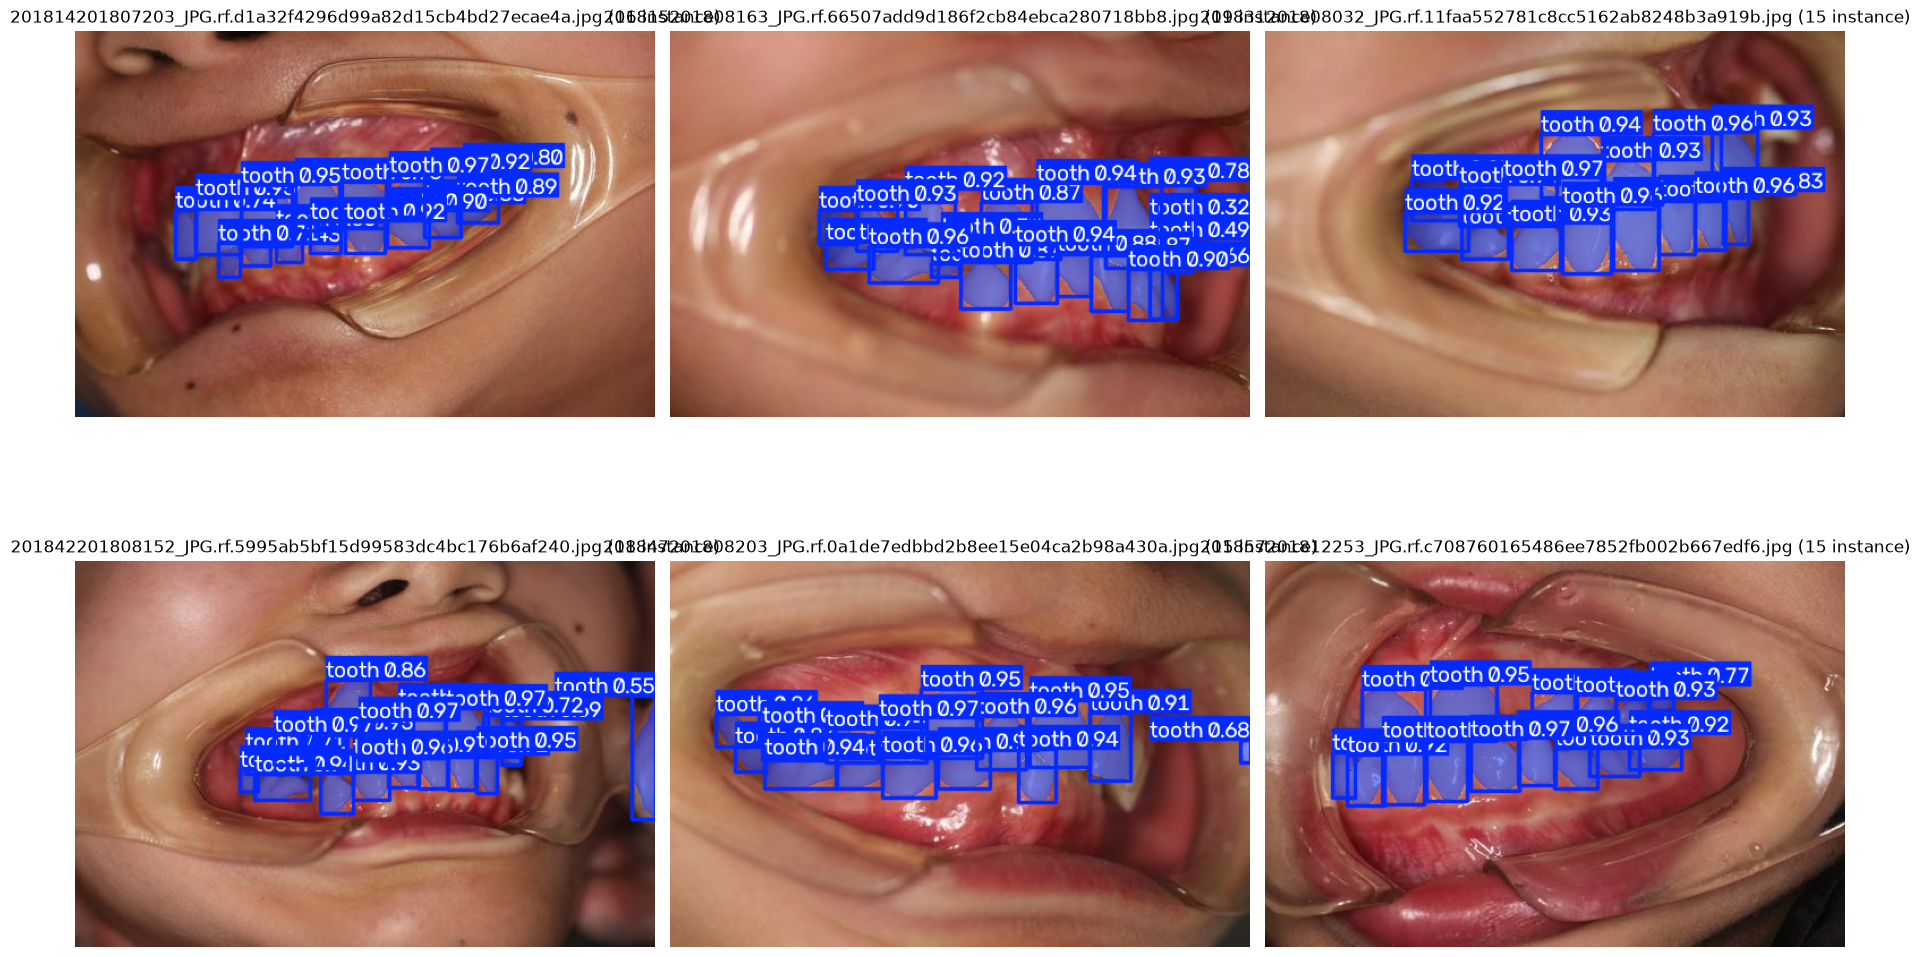

In [7]:
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

BEST_WEIGHTS = Path(model.trainer.save_dir) / "weights" / "best.pt"
model_best = YOLO(str(BEST_WEIGHTS))

train_images_dir = YOLO_ROOT / data_cfg["train"]
sample_images = sorted(train_images_dir.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, img_path in zip(axes.flat, sample_images):
    pred = model_best.predict(source=str(img_path), conf=0.25, verbose=False)[0]
    plotted = pred.plot()[:, :, ::-1]  # BGR -> RGB
    n_instances = 0 if pred.masks is None else len(pred.masks)
    ax.imshow(plotted)
    ax.set_title(f"{img_path.name} ({n_instances} instance)")
    ax.axis("off")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))


## Catatan pilot — hasil & kesimpulan

**Angka (indikatif, test set cuma 3 gambar):** mask mAP50-95 = 0.856, mask mAP50 = 0.984 — tinggi, tapi ini TIDAK cukup buat nyimpulkan sukses (lihat poin di bawah).

**Verifikasi visual (Section 6 & 7), dicek terhadap 3 kriteria awal:**
1. **Jumlah instance TIDAK masuk akal** — di `conf=0.25` (default), model ngeluarin 14-28 instance per foto padahal gigi yang kelihatan cuma ~8-10. Setelah threshold diperketat (`conf=0.5, iou=0.4`), turun ke 11-16, tapi **masih ada duplikat jelas** (box dobel numpuk di gigi yang sama, dengan confidence tinggi 0.9-1.0 di kedua box — bukan noise lemah yang harusnya ke-filter). Ini gagal di kriteria #1.
2. **Bentuk mask per-gigi cukup wajar** — mask yang terbentuk (walau dobel) bentuknya mengikuti kontur gigi dengan baik, bukan blob campur aduk seperti hasil auto-label SAM3 gagal sebelumnya.
3. **Generalisasi ke pasien baru (Section 7) bekerja** — model tetap bisa nge-mask gigi dengan bentuk masuk akal di 3 foto yang sama sekali belum pernah dilihat, sinyal bagus bahwa yang dipelajari bukan sekadar hafalan 14 foto training.

**Kesimpulan:** mAP tinggi vs instance count berantakan itu BUKAN kontradiksi — mAP tidak menghukum deteksi duplikat yang menumpuk di satu ground-truth, jadi memang tidak bisa dipakai sendirian buat nilai kualitas (persis dugaan awal di rencana). Duplikat ini juga sudah dicoba diatasi lewat NMS tuning (conf/iou) dan cuma berkurang sebagian, bukan hilang — mengindikasikan akar masalahnya **kurang data training** (14 gambar), bukan cuma setting inference yang salah.

**Keputusan:** approach-nya (SAM-assisted manual polygon per gigi di Roboflow + YOLO11-seg) *valid dan layak dilanjutkan* — mask per-gigi yang dihasilkan bagus dan model bisa belajar generalisasi. Tapi 14-20 gambar jelas belum cukup buat model belajar suppress deteksi duplikat dengan baik. **Lanjut ke anotasi 50-100 gambar penuh (lateral + frontal)** sebagai langkah berikutnya, dengan ekspektasi masalah duplikat ini membaik seiring data bertambah — bukan mengulang dari nol karena approach-nya sendiri sudah terbukti jalan.

## Update v2 (108 foto) — hasil & kesimpulan

**Angka (test set 16 foto, 253 instance — jauh lebih bisa dipercaya dari test v1 yang cuma 3 foto):**
- Box: precision=0.968, recall=0.933, mAP50=0.961, mAP50-95=0.844
- Mask: precision=0.968, recall=0.933, mAP50=0.951, mAP50-95=0.810

**Verifikasi visual (Section 6 & 7 di-run ulang dengan model v2):**
1. **Duplikat berkurang, TAPI belum hilang total** — di 3 foto unseen yang sama persis (Section 7): jumlah instance turun (v1: 15/16/11 → v2: 13/13/12), dan **1 false-positive non-gigi di tepi retractor yang muncul di v1 sekarang hilang**. Tapi masih ada sisa overlap ringan di area distal/molar (beberapa foto), jadi kriteria #1 (jumlah instance masuk akal) membaik tapi belum 100% bersih.
2. **Bentuk mask tetap rapi** mengikuti kontur gigi, konsisten dengan v1.
3. **Generalisasi ke pasien baru tetap bekerja**, malah kualitasnya lebih baik dari v1 di 3 foto unseen yang sama.

**Kesimpulan: hipotesis di catatan v1 di atas ("akar masalahnya kurang data, bukan setting inference") terbukti benar arahnya** — nambah dari 14→76 foto training nyata-nyata ngurangin duplikat & false-positive, tanpa ubah kode/threshold apapun. Tapi belum sepenuhnya tuntas — kemungkinan karena area molar/distal (yang paling crowded & paling sering jadi sumber duplikat) masih under-represented dibanding area depan (insisivus/kaninus) di data training.

**Dampak nyata**: model v2 ini juga yang bikin `07_lateral-unseen-test.ipynb` (pipeline penuh: segmentasi -> anchor -> FDI -> overjet/Angle) sempat gagal capai posisi molar (M1) di beberapa foto -- itu pakai model v1/v2 sebelumnya, worth di-re-test dengan `baseline_seg-3` ini buat lihat apakah cakupannya ikut membaik.

**Rekomendasi**: kalau mau ngejar duplikat molar sampai bersih total, prioritasin anotasi tambahan **khusus area molar/distal** (bukan nambah foto secara acak) di batch berikutnya -- sama seperti saran buat data kaninus sebelumnya.

## Section 7: Test ke gambar baru (belum pernah dianotasi)

Coba model ke 3 foto lateral yang **sama sekali belum ada di 20 gambar pilot** (pasien beda, belum pernah dilihat model) — ini cek generalisasi yang lebih jujur dibanding overlay ke gambar training di Section 6.

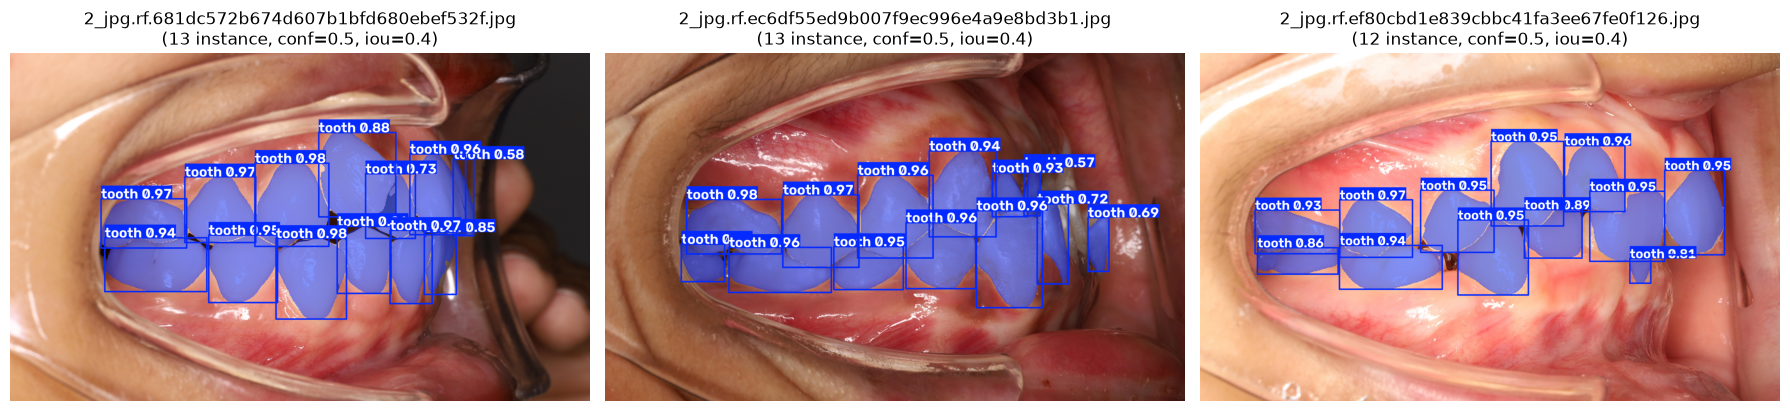

In [8]:
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image
from pathlib import Path

UNSEEN_DIR = Path("/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/lateral_unseen_test")
unseen_images = sorted(UNSEEN_DIR.glob("*.jpg"))

BEST_WEIGHTS = Path(model.trainer.save_dir) / "weights" / "best.pt"
model_best = YOLO(str(BEST_WEIGHTS))

# Section 6/7 awal pakai conf=0.25, iou=0.7 (default) -> banyak box dobel numpuk di gigi
# yang sama (NMS kelewat longgar). Coba lebih ketat di sini: conf naik, iou turun.
PREDICT_CONF = 0.5
PREDICT_IOU = 0.4

fig, axes = plt.subplots(1, len(unseen_images), figsize=(6 * len(unseen_images), 6))
if len(unseen_images) == 1:
    axes = [axes]
for ax, img_path in zip(axes, unseen_images):
    pred = model_best.predict(
        source=str(img_path),
        conf=PREDICT_CONF,
        iou=PREDICT_IOU,
        verbose=False,
    )[0]
    plotted = pred.plot()[:, :, ::-1]  # BGR -> RGB
    n_instances = 0 if pred.masks is None else len(pred.masks)
    ax.imshow(plotted)
    ax.set_title(f"{img_path.name}\n({n_instances} instance, conf={PREDICT_CONF}, iou={PREDICT_IOU})")
    ax.axis("off")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))
